In [17]:
from sklearn.cluster import KMeans, k_means
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler


In [18]:
ANBIMA_FILENAME = f'../data/processed/anbima_pca.csv'
df = pd.read_csv(ANBIMA_FILENAME).dropna()
X = df.drop(
    ['nquest'],
    axis='columns').dropna()

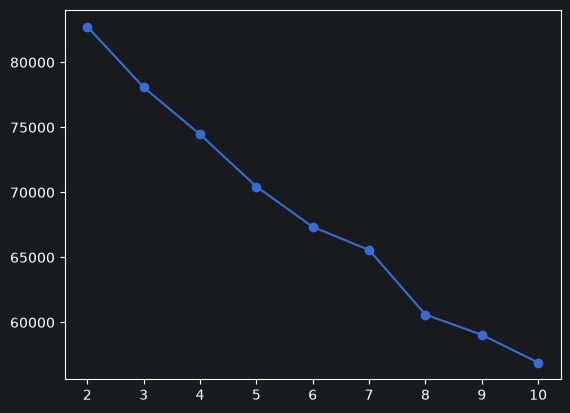

In [19]:
valores_inercia = []

for k in range (2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    valores_inercia.append(kmeans.inertia_)

plt.plot(range(2, 11), valores_inercia, marker='o')


In [20]:
K_IDEAL = 7

kmeans_final = KMeans(n_clusters=K_IDEAL, random_state=42)

perfis = kmeans_final.fit_predict(X)

df_resultado = df.copy()
df_resultado['cluster'] = perfis

print("=== CONTAGEM DE INVESTIDORES POR CLUSTER ===")
print(df_resultado['cluster'].value_counts().sort_index())

# ==========================================
# EXTRAÇÃO DOS CENTRÓIDES (VETOR IDEAL)
# ==========================================

# O atributo .cluster_centers_ guarda as coordenadas exatas do meio de cada tribo
centroides_array = kmeans_final.cluster_centers_

# Vamos transformar isso num DataFrame para ficar fácil de ler e exportar depois
df_centroides = pd.DataFrame(
    centroides_array,
    columns=X.columns # Usa os nomes das 9 colunas do PCA (PC1, PC2...)
)

# Adiciona uma coluna amigável para identificar o perfil
df_centroides.insert(0, 'Perfil_ID', range(K_IDEAL))

print("\n=== COORDENADAS DOS CENTRÓIDES (O VETOR IDEAL DE CADA PERFIL) ===")
print(df_centroides)

# Salve o resultado final para o Matchmaker usar depois
df_resultado.to_csv('../data/processed/anbima_investidores_clusterizados.csv', index=False)
df_centroides.to_csv('../data/processed/centroides_perfis.csv', index=False)
print("\nDados e Centróides salvos com sucesso na pasta data/processed/!")


=== CONTAGEM DE INVESTIDORES POR CLUSTER ===
cluster
0    1429
1     535
2    1045
3    1067
4      69
5     728
6     528
Name: count, dtype: int64

=== COORDENADAS DOS CENTRÓIDES (O VETOR IDEAL DE CADA TRIBO) ===
   Tribo_ID       PC1       PC2       PC3       PC4       PC5       PC6  \
0         0 -1.841529 -0.802730  0.540542 -0.223096 -0.267502 -0.040922   
1         1  0.879626 -1.420810 -1.624615  0.007011 -0.044064 -0.577080   
2         2  0.701803  1.102825  0.166845  0.111734 -0.575581 -0.427015   
3         3  2.703679 -0.256194  0.653073 -0.210722  0.405459 -0.076666   
4         4  0.431983 -2.880655 -2.173091  4.475180  0.252336  1.233298   
5         5 -2.224109  1.239918 -0.538833  0.130155  0.864768 -0.375419   
6         6  0.250152  0.614104 -0.439839  0.037103 -0.136875  2.052002   

        PC7       PC8       PC9      PC10      PC11      PC12      PC13  \
0  0.174325  0.034174  0.029319  0.009996  0.224347 -0.010174 -0.079079   
1  0.034502 -0.634400  0.129139 -0

In [ ]:
df_loadings = pd.read_csv('../data/processed/pca_loadings.csv', index_col=0)
